In [35]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

In [36]:
import numpy as np

def normalize_abundance_dict(abundance_dict):
    """
    将丰度字典的 value 归一化，使其和为 1。
    
    参数：
        abundance_dict (dict): 例如 {'A': 10, 'B': 30, 'C': 60}
    
    返回：
        dict: 归一化后的字典，例如 {'A': 0.1, 'B': 0.3, 'C': 0.6}
    """
    values = np.array(list(abundance_dict.values()), dtype=float)
    total = values.sum()
    if total > 0:
        normalized_values = values / total
    else:
        normalized_values = np.zeros_like(values)
    
    # 保留 key 的对应关系
    normalized_dict = dict(zip(abundance_dict.keys(), normalized_values))
    return normalized_dict


# input and output

In [37]:
experiment_file = '../../Data/L-DOPA_experimentdata.xlsx'

In [38]:
experiment_data = pd.read_excel(experiment_file,sheet_name = 'Sheet2')
experiment_data.head(3)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,0520A,0519A,0609A,0511A,0506A,0427A,0705A,...,0612A,0611A,0610C,0602B,0519B,0908B,0805A,0721C,0707B,0610A
0,Taxonomic rank,NCBI,strain,wulu1215_BKDL210003784-1A-9.txt,wulu1215_BKDL210003784-1A-8.txt,wulu1215_BKDL210003784-1A-7.txt,wulu1215_BKDL210003784-1A-5.txt,wulu1215_BKDL210003784-1A-4.txt,wulu1215_BKDL210003784-1A-3.txt,wulu1215_BKDL210003784-1A-20.txt,...,wulu1215_BKDL210003784-1A-18.txt,wulu1215_BKDL210003784-1A-17.txt,wulu1215_BKDL210003784-1A-16.txt,wulu1215_BKDL210003784-1A-13.txt,wulu1215_BKDL210003784-1A-11.txt,wulu0219_3-200908B_FKDL210012333-1a-9_HFJ7LCCX...,wulu0219_1-200805A_FKDL210012331-1a-11_HFJ7LCC...,wulu0219_1-200721C_FKDL210012331-1a-3_HFJ7LCCX...,wulu0219_1-200707B_FKDL210012331-1a-6_HFJ7LCCX...,wulu0219_1-200610A_FKDL210012331-1a-2_HFJ7LCCX...
1,C,1236,Gammaproteobacteria,4.93,2.59,9.96,1.11,2,0.65,3.7,...,1.26,7.44,0.72,0.6,0.72,0.58,0.65,1.58,3.2,1.67
2,C,1760,Actinobacteria,0.58,0.31,4.07,3.67,5.13,0.69,1.42,...,25.34,10.35,20.87,2.55,1.25,5.95,0.19,9.36,1.32,5.64


In [39]:
def deal_sampleinfo_level(experiment_data, level='F'):
    # 按照 level 筛选
    filtered = experiment_data[experiment_data['Unnamed: 0'] == level]
    # 遍历每一行，取 index 和 'Unnamed: 2' 的内容
    experiment_data_levellist = [
        (idx, str(row['Unnamed: 2']).strip())
        for idx, row in filtered.iterrows()
    ]
    return experiment_data_levellist

experiment_data_levellist = deal_sampleinfo_level(experiment_data, level='F')
experiment_data_levellist

# experiment_data_levellist = deal_sampleinfo_level(experiment_data, level='S')
experiment_data_levellist

[(178, 'Myxococcaceae'),
 (179, 'Archangiaceae'),
 (180, 'Polyangiaceae'),
 (181, 'Planctomycetaceae'),
 (182, 'Spirochaetaceae'),
 (183, 'Leptospiraceae'),
 (184, 'Methylococcaceae'),
 (185, 'Acetobacteraceae'),
 (186, 'Legionellaceae'),
 (187, 'Moraxellaceae'),
 (188, 'Neisseriaceae'),
 (189, 'Alcaligenaceae'),
 (190, 'Enterobacteriaceae'),
 (191, 'Vibrionaceae'),
 (192, 'Pasteurellaceae'),
 (193, 'Bartonellaceae'),
 (194, 'Rickettsiaceae'),
 (195, 'Chlamydiaceae'),
 (196, 'Bacteroidaceae'),
 (197, 'Cardiobacteriaceae'),
 (198, 'Anaplasmataceae'),
 (199, 'Halanaerobiaceae'),
 (200, 'Chromatiaceae'),
 (201, 'Chloroflexaceae'),
 (202, 'Nostocaceae'),
 (203, 'Scytonemataceae'),
 (204, 'Rivulariaceae'),
 (205, 'Prochloraceae'),
 (206, 'Micrococcaceae'),
 (207, 'Streptococcaceae'),
 (208, 'Corynebacteriaceae'),
 (209, 'Mycobacteriaceae'),
 (210, 'Streptosporangiaceae'),
 (211, 'Thermomonosporaceae'),
 (212, 'Actinomycetaceae'),
 (213, 'Streptomycetaceae'),
 (214, 'Pseudonocardiaceae'),
 (

In [40]:
sampleID_list = list(experiment_data.columns)
sampleID_list = [x for x in sampleID_list if 'Unnamed' not in x]
sampleID_list

['0520A',
 '0519A',
 '0609A',
 '0511A',
 '0506A',
 '0427A',
 '0705A',
 '0421A',
 '0616A',
 '0612A',
 '0611A',
 '0610C',
 '0602B',
 '0519B',
 '0908B',
 '0805A',
 '0721C',
 '0707B',
 '0610A']

In [41]:
def get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist):
    sampleID_abundance = experiment_data[sampleID].to_list()
    abundance_dict = {}
    for index, level in experiment_data_levellist:   # ✅ 不要用 .items()
        if level not in abundance_dict:
            abundance_dict[level] = sampleID_abundance[index]
        else:
            abundance_dict[level] += sampleID_abundance[index]
    abundance_dict = {k:v for k,v in abundance_dict.items() if v>0}
    
    return abundance_dict

sampleID = '0520A'
get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)

{'Spirochaetaceae': 0.01,
 'Moraxellaceae': 0.03,
 'Enterobacteriaceae': 4.02,
 'Vibrionaceae': 0.01,
 'Pasteurellaceae': 0.64,
 'Bacteroidaceae': 12.14,
 'Micrococcaceae': 0.01,
 'Streptococcaceae': 2.93,
 'Corynebacteriaceae': 0.01,
 'Actinomycetaceae': 0.05,
 'Streptomycetaceae': 0.01,
 'Hominidae': 0.02,
 'Myoviridae': 0.01,
 'Siphoviridae': 0.01,
 'Bifidobacteriaceae': 0.47,
 'Veillonellaceae': 1.18,
 'Clostridiaceae': 0.18,
 'Rhodobacteraceae': 0.01,
 'Xanthomonadaceae': 0.02,
 'Lactobacillaceae': 0.03,
 'Sphingomonadaceae': 0.01,
 'Flavobacteriaceae': 0.02,
 'Campylobacteraceae': 0.02,
 'Comamonadaceae': 0.01,
 'Leuconostocaceae': 0.01,
 'Enterococcaceae': 0.33,
 'Rhizobiaceae': 0.01,
 'Coriobacteriaceae': 0.02,
 'Sphingobacteriaceae': 0.01,
 'Staphylococcaceae': 0.01,
 'Burkholderiaceae': 0.01,
 'Erysipelotrichaceae': 2.97,
 'Pseudomonadaceae': 0.03,
 'Rikenellaceae': 0.04,
 'Prevotellaceae': 0.02,
 'Lachnospiraceae': 19.37,
 'Peptostreptococcaceae': 0.72,
 'Eubacteriaceae': 0.

In [42]:
import math
def calculate_sampleID_score(family_list, abund_dict, enzyme_counts_dict):
    score = 0
    for family in family_list:
        abund = abund_dict.get(family, 0)/100
        enzyme_count = enzyme_counts_dict.get(family, 0)
        # score += math.log1p((abund ** (1/3)) * (enzyme_count ** 3))
        # score += math.log10((abund ** (1/3)) * (enzyme_count ** 3) +1)
        score += abund ** (1) * (enzyme_count ** 0)
        # score += (abund ** (1)) * (enzyme_count ** 1)
        # print(family,abund,enzyme_count,score)
    return score

# levodopa

In [43]:

##############family level########################
enzyme_counts_dict = {'Bifidobacteriaceae': 1,
 'Bacteroidaceae': 1,
 'Porphyromonadaceae': 1,
 'Rikenellaceae': 1,
 'Enterococcaceae': 1,
 'Streptococcaceae': 1,
 'Turicibacteraceae': 1,
 'Clostridiaceae': 1,
 'Lachnospiraceae': 1,
 'Peptostreptococcaceae': 1,
 'Ruminococcaceae': 1,
 'Veillonellaceae': 1,
 'Erysipelotrichaceae': 1,
 'Alcaligenaceae': 1,
 'Enterobacteriaceae': 1}

In [44]:
# 按 key 相除（避免除以0）
# enzyme_counts_dict = {
#     k: (enzyme_counts_dict.get(k, 0) / strain_counts[k]) if strain_counts[k] != 0 else 0
#     for k in strain_counts.keys()
# }

# enzyme_counts_dict

# 计算每个样本的score

In [45]:
##############family level########################
height_data_single = {
    'Enterococcaceae': [],  
    # 'Streptococcaceae': [],
    # 'Turicibacteraceae': [],
    # 'Enterobacteriaceae': [],
    # 'Alcaligenaceae': [],
    # 'Veillonellaceae': [],
    # 'Peptostreptococcaceae': [],
    # 'Porphyromonadaceae': [],
    # 'Erysipelotrichaceae': [],
    # 'Clostridiaceae': [],
    # 'Bifidobacteriaceae': [],
    # 'Rikenellaceae': [],
    # 'Bacteroidaceae': [],
    # 'Ruminococcaceae': [],
    # 'Lachnospiraceae': [],
}

In [46]:
dopa_dict = {
'0611A':3.692,
'0707B':4.665,
'0610C':5.414,
'0519A':6.608,
'0421A':6.811,
'0612A':10.225,
'0721C':10.488,
'0805A':11.191,
'0705A':11.405,
'0511A':11.585,
'0427C':12,  
'0610A':12.681,  
'0519B':13.088,  
# '0609A':13.368,  
# '0520A':14.545,  
'0908B':15.246,  
'0602B':15.567,  
'0616A':15.901,  
'0427A':16.828,  
'0506A':19.051,  
}
dopa_dict = {k:(30-v)/30 for k,v in dopa_dict.items()}

In [47]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np


result = {}
for family,v in height_data_single.items():
    # family = 'Porphyromonadaceae'
    print(family)
    height_data_single_tmp = {family:[],}
    
    score_dict = {}
    for sampleID in sampleID_list:
        abund_dict = get_sampleID_abundance(sampleID,experiment_data,experiment_data_levellist)
        abund_dict = {k:v/100 for k,v in abund_dict.items()}
        # print(sampleID,abund_dict)
        # abund_dict = normalize_abundance_dict(abund_dict)
        score = calculate_sampleID_score(height_data_single_tmp.keys(), abund_dict, enzyme_counts_dict)
        score_dict[sampleID] = score 
        
    try:
        # ===== 数据准备 =====
        keys = list(score_dict.keys())
        # keys = [x for x in keys if x not in ['0609A', '0520A', '0506A']]
        keys = [x for x in keys if x not in ['0520A', '0609A']]
        x = [dopa_dict[k] for k in keys]
        y = [score_dict[k] for k in keys]

        # ===== Pearson 相关性 =====
        # r, p = pearsonr(x, y)
        # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
        r, p = pearsonr(x, np.log10(y))
        print(f"Pearson r = {r:.3f}, p = {p:.3e}")

        result[family] = (r,p)
    except:
        pass

Enterococcaceae
Pearson r = 0.289, p = 2.603e-01


In [48]:
result

{'Enterococcaceae': (0.2891808153539628, 0.2602633193201764)}

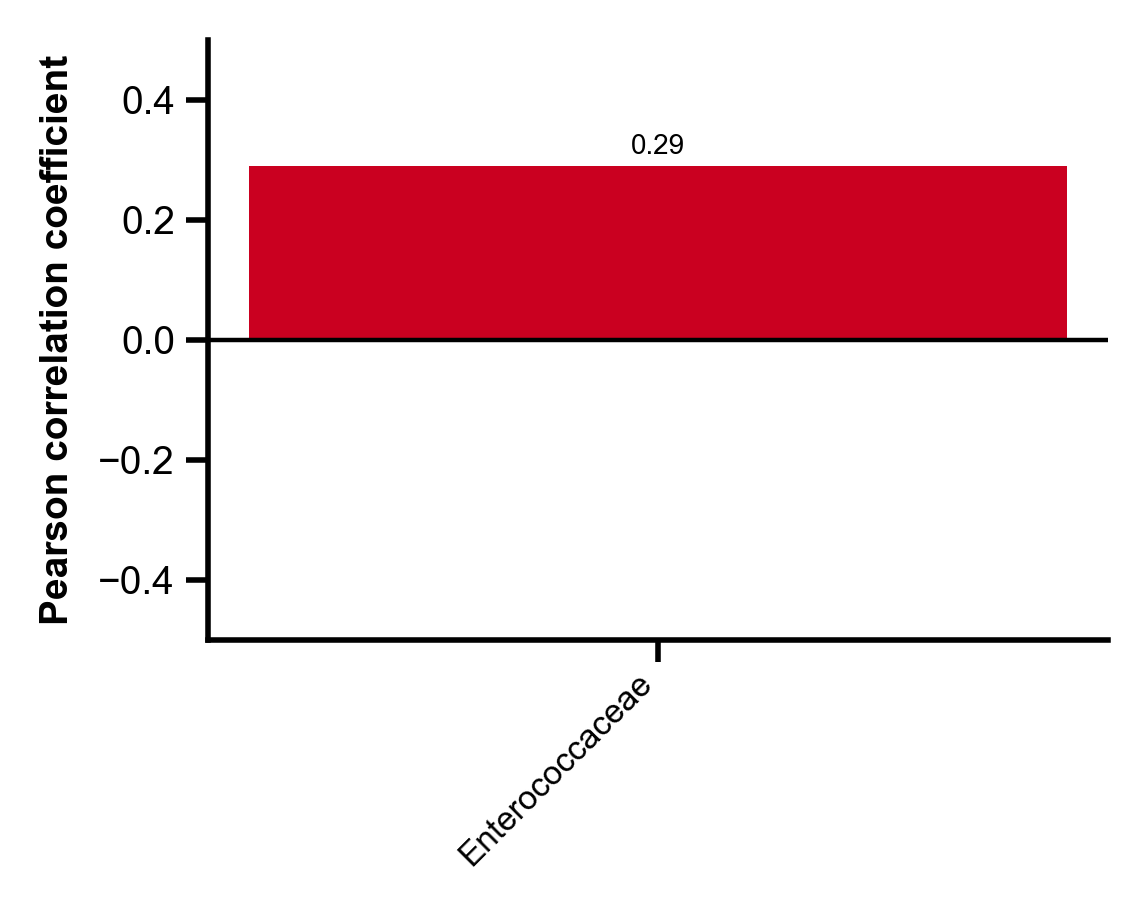

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 数据准备 =====
# result = {k:v for  k,v in result.items() if k!='Enterococcaceae'}

# 过滤掉 nan 值，并按数值从大到小排序
clean_data = {k: v[0] for k, v in result.items() if not np.isnan(v[0])}
sorted_items = sorted(clean_data.items(), key=lambda x: x[1], reverse=True)
keys = [item[0] for item in sorted_items]
values = [item[1] for item in sorted_items]

# ===== 画布 & 样式 =====
# 保持了你习惯的 1.8x1.8 小画布和高 DPI（如果柱子太挤，可以把 figsize 调大，比如 (4, 3)）
plt.figure(figsize=(3, 2), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
# 去掉顶部和右侧边框，保留底部和左侧
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.set_position([0.2, 0.2, 0.75, 0.75]) 

# ===== 柱状图绘制 =====
# 根据正负值设置颜色（参考了科研常用配色：正红负绿，你也可以换成你喜欢的蓝色系）
colors = ['#ca0020' if x > 0 else '#0571b0' for x in values]
bars = plt.bar(keys, values, color=colors, width=0.6)

# 添加 y=0 的基准线
plt.axhline(0, color='black', linewidth=0.8)

# ===== 坐标轴与标签 =====
plt.ylabel("Pearson correlation coefficient", fontsize=7, fontweight='bold')

# 锁定 Y 轴范围为 -1 到 1（相关系数的标准范围）
plt.ylim(-0.5, 0.5)

# 设置刻度样式
plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

# X轴标签旋转，防止重叠
plt.xticks(rotation=45, ha='right', fontsize=6)

# 在柱子上方/下方显示具体数值
for bar in bars:
    yval = bar.get_height()
    # 正值显示在上方，负值显示在下方
    va = 'bottom' if yval > 0 else 'top'
    offset = 0.01 if yval > 0 else -0.01
    plt.text(bar.get_x() + bar.get_width()/2, yval + offset, 
             round(yval, 2), ha='center', va=va, fontsize=5)

plt.show()

In [50]:
clean_data

{'Enterococcaceae': 0.2891808153539628}

Pearson r = 0.316, p = 2.170e-01
Pearson r = 0.289, p = 2.603e-01


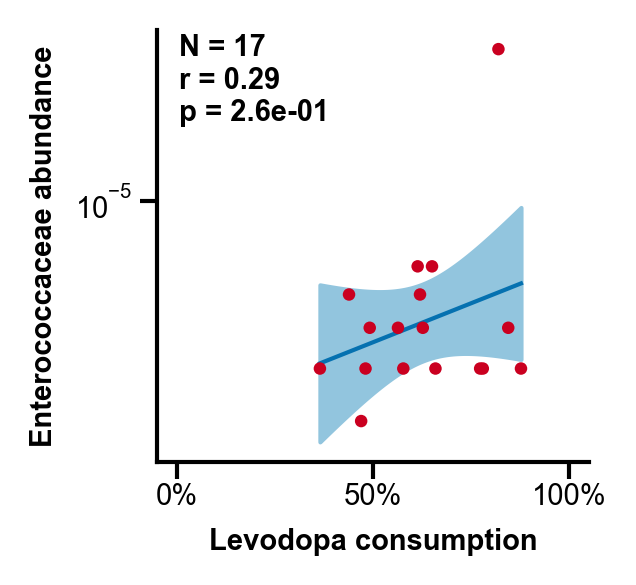

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
import numpy as np

# ===== 数据准备 =====
keys = list(score_dict.keys())
keys = [x for x in keys if x not in ['0520A', '0609A']]

x = np.array([dopa_dict[k] for k in keys])
y = np.array([score_dict[k] for k in keys])

# ===== Pearson（基于 log y，更合理）=====
r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p = {p:.3e}")
r, p = pearsonr(x, np.log10(y))
print(f"Pearson r = {r:.3f}, p = {p:.3e}")

# ===== 回归（log y）=====
slope, intercept, r_value, p_value, std_err = linregress(x, np.log10(y))

x_fit = np.linspace(min(x), max(x), 100)
y_fit_log = intercept + slope * x_fit
y_fit = 10 ** y_fit_log

# ===== 纺锤型 CI（regression CI）=====
n = len(x)
x_bar = np.mean(x)
Sxx = np.sum((x - x_bar)**2)

# 残差标准误
s_err = np.sqrt(np.sum((np.log10(y) - (intercept + slope * x))**2) / (n - 2))

# CI宽度（随x变化 → 纺锤型）
ci = 1.96 * s_err * np.sqrt(
    1/n + (x_fit - x_bar)**2 / Sxx
)

y_upper = 10 ** (y_fit_log + ci)
y_lower = 10 ** (y_fit_log - ci)

# ===== 画布 =====
plt.figure(figsize=(1.8, 1.8), dpi=300)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)
ax.set_position([0.2, 0.2, 0.8, 0.8]) 

# ===== 散点 =====
plt.scatter(x, y, s=9, alpha=1, color='#ca0020', edgecolors='none', zorder=3)

# ===== 回归线 + 纺锤CI =====
plt.plot(x_fit, y_fit, color='#0571b0', linewidth=1, zorder=2)
plt.fill_between(x_fit, y_lower, y_upper,
                 color='#92c5de', alpha=1, zorder=1)

# ===== label（可选）=====
# for i, k in enumerate(keys):
#     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

# ===== log y轴 =====
from matplotlib.ticker import LogLocator

plt.yscale("log")

ax = plt.gca()
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))

# ===== 统计标注 =====
plt.text(0.05, 0.99,
         f"N = {len(x)}\nr = {r:.2f}\np = {p:.1e}",
         transform=plt.gca().transAxes,
         fontsize=7, fontweight='bold', va="top", ha='left')

# ===== 坐标轴 =====
plt.xlabel("Levodopa consumption", fontsize=7, fontweight='bold')
# plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')
plt.ylabel("Enterococcaceae abundance", fontsize=7, fontweight='bold')

plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

plt.xlim(-0.05, 1.05)
import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# plt.ylim(5e20, 3e21)

plt.savefig('../../Figure/Figure-S7.pdf', dpi=400, bbox_inches='tight')
# plt.savefig('../../Figure/Figure-S7.tiff',dpi=400,bbox_inches='tight',format='tiff')
plt.show()